<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week10_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

p393 - 417
## 7장 시계열 분석
### 7.5 LSTM
: '게이트'라는 장치를 통해 중요한 정보는 장기 기억하고, 불필요한 정보는 즉시 삭제함으로써 긴 데이터에서도 성능을 유지하는 스마트한 RNN

**7.5.1 LSTM 구조**
> RNN은 가중치가 업데이트되는 과정에서 기울기 소멸 문제 발생 -> LSTM, GRU 같은 확장 RNN사용

1. LSTM 구조
  - 순전파 : 망각게이트, 입력게이트, 출력게이트 요소를 은닉층의 각 뉴런에 추가함
    - 망각 게이트(forget gate) : 과거 정보를 보존하는 정도 결정 (과거 정보와 현재 데이터 입력받아 시그모이드 출력값을 과거 정보에 곱함)
      - $h_t-1$ : 0~1 출력값 (이전 은닉층에서 입력됨)
      - $x_t$ : 새로운 입력값  
      > 수식
      > $f_t= σ(w_f[h_{t-1}, x_t])$
      > $ c_t= f_t·c_{t-1}$
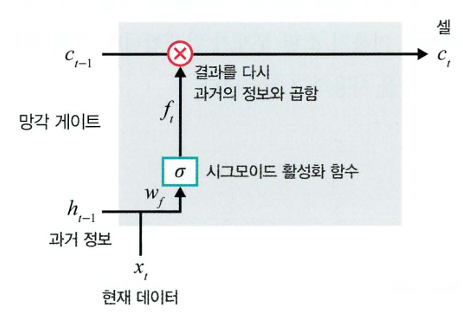
               

- 순전파
  - 입력게이트 : 현재 정보를 기억하기 위함, 과거 정보+현재 데이터 -> 시그모이드&하이퍼볼릭 탄젠트 함수 기반으로 현재 정보 보존량 결정
  > 현재 메모리에 새 정보 반영 여부 결정
  > 계산 값 1 -> 입력 xt 허용, 0이면 차단

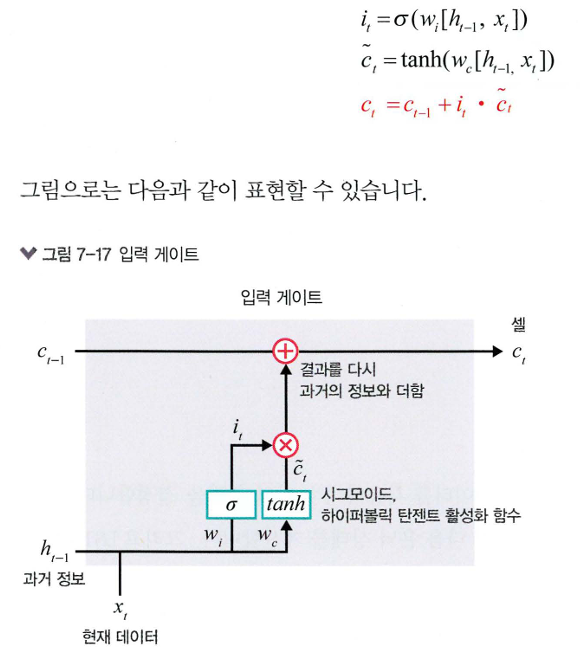

- 셀 : 각 단계에 대한 은닉노드를 메모리 셀이라고 함 -> 기울기 소멸 문제 해결
  - 망각, 입력 게이트의 이전 단계 셀 정보를 계산하여 현재 단계의 셀 상태 업데이트함

  - 수식
  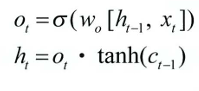

  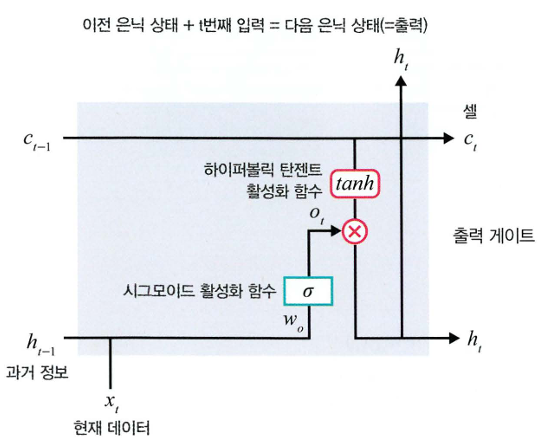


> 망각, 입력, 출력 게이트 전체 그림

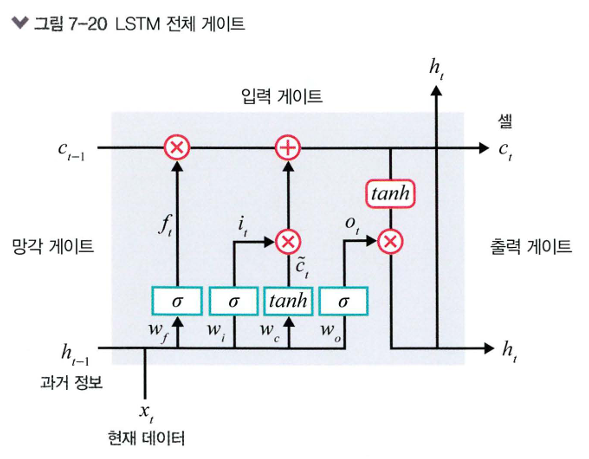

2. LSTM 역전파
> LSTM 은 셀을 통해 역전파를 수행하여 중단 없는 기울기이다. = 최종 오차가 셀을 통해 모든 노드에 전파됨

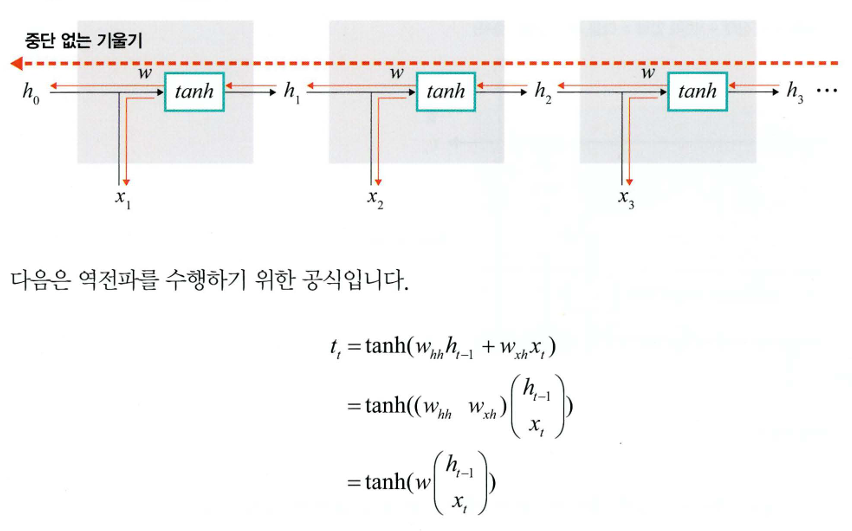

> 셀 내부적으로는 오차가 입력(xt)로 전파됨



**7.5.2 LSTM 셀 구현**
- MNIST 데이터 이용

In [ ]:
# 라이브러리 호출
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device= torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# GPU 사용에 필요
cuda= True if torch.cuda.is_available() else False
Tensor= torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [ ]:
# 데이터 전처리
import torchvision.transforms as transforms

mnist_transform= transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(1.0,))
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 데이터셋 내려받기
from torchvision.datasets import MNIST

download_root= '/content/drive/MyDrive/ESSA'

train_dataset=MNIST(download_root, transform=mnist_transform, train=True, download=True)
valid_dataset= MNIST(download_root, transform=mnist_transform, train=False, download=True)
test_dataset= MNIST(download_root, transform=mnist_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.54MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.1MB/s]


```
train_dataset=MNIST(download_root, transform=mnist_transform, train=True, download=True)
```
필요한 파라미터
1. MNIST 내려받을 위치
2. transform : 앞에서 정의했던 데이터 전처리 적용해줌
3. train : True 설정 시 훈련용, False는 테스트용 데이터셋
4. download : True 설정 시 내려받는 위치에 해당파일 있으면 다운 받지않음

In [ ]:
# 데이터셋을 메모리로 가져오기
batch_size= 64
train_loader= DataLoader(dataset= train_dataset,
                         batch_size= batch_size,
                         shuffle=True)
valid_loader= DataLoader(dataset= valid_dataset,
                         batch_size= batch_size,
                         shuffle=True)
test_loader= DataLoader(dataset= test_dataset,
                         batch_size= batch_size,
                         shuffle=True)

In [ ]:
# 변수 값지정
batch_size= 100
n_iters= 6000
num_epochs= n_iters/ (len(train_dataset)/batch_size)
num_epochs= int(num_epochs)

> LSTM 셀에 대한 네트워크 구축
- LSTM 셀에 집중함

In [17]:
# LSTM 셀에 대한 네트워크 구축
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size, bias= True):
        super(LSTMCell, self).__init__()
        self.input_size= input_size
        self.hidden_size= hidden_size
        self.bias= bias
        self.x2h= nn.Linear(input_size, 4*hidden_size, bias=bias)  ## 1-1
        self.h2h= nn.Linear(hidden_size, 4*hidden_size, bias=bias)  ## 1-2
        self.reset_parameters()

    # 모델 파라미터 초기화
    def reset_parameters(self):
        std= 1.0 / math.sqrt(self.hidden_size)
        for w in self.parameters():
            w.data.uniform_(-std, std)   ## 2

    def forward(self, x, hidden):
        hx, cx = hidden
        x= x.view(-1, x.size(1))

        # 입력, 은닉층 합침
        gates= self.x2h(x)+ self.h2h(hx) ## 1-3
        gates= gates.squeeze() ## 3
        ingate, forgetgate, cellgate, outgate= gates.chunk(4,1)  ## 1-4

        ingate= F.sigmoid(ingate)
        forgetgate= F.sigmoid(forgetgate)
        cellgate= F.tanh(cellgate)
        outgate= F.sigmoid(outgate)

        cy= torch.mul(cx, forgetgate) + torch.mul(ingate, cellgate)  ## 4
        hy= torch.mul(outgate, F.tanh(cy))  ## 4-1

        return(hy, cy)



> 1-1, 1-2 에서 4*hidden_size 가 사용되는 이유? 왜 4를 곱할까?
- 뒤에서 게이트를 계산하여 구하고 gates.chunk(4,1) 로 4개로 쪼개기 때문

```
gates= self.x2h(x)+ self.h2h(hx)

=

gates=
F.linear(input, w_ih, b_ih)
+
F.linear(hx, w_hh, b_hh)

# 입력되는 훈련 데이터셋 칼럼수, 입력층-은닉층 사이 가중치, 바이어스
+
# 은닉칭 특성 수, 은닉층-은닉층 가중치, 사이어스
```

- torch.chunk() 사용방법
  - 텐서를 몇개로 쪼갤지 설정
  - 어떤 차원을 기준으로 쪼갤지 결정
  - (4,1) : 4개 텐서, dim=1 열 단위 분할

> ##3 torch.squeeze()는 텐서 차원 줄임
  - torch.FloatTensor([[1],[2]]).squeeze()
  - (2x1) 텐서 -> (2,) 1차원 벡터

> 4-1, 4-2 : 하나의 LSTM 셀 통과 시 셀(ct) 상태와 은닉(ht) 상태가 출력
- 셀 상태 <- 입력, 망각, 셀 게이트로 계산
- 은닉 상태 <- 출력게이트에 의해 계산
```
x=torch.FloatTensor([[1],[2]])
torch.mul(x,3) # x라는 텐서의 원소에 2 곱함
```

In [18]:
# LSTM 셀의 전반적인 네트워크
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, bias=True):
        super(LSTMModel, self).__init__()

        # 은닉층 뉴런/유닛 개수
        self.hidden_dim= hidden_dim

        self.layer_dim= layer_dim
        self.lstm= LSTMCell(input_dim, hidden_dim, layer_dim)  ## 1
        self.fc= nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        #GPU 사용 유무 확인
        if torch.cuda.is_available():

            # (은닉층 계층 개수, 배치 크기, 은닉층 뉴런 개수) 형태 갖는 은닉 상태를 0으로 초기화
            h0= Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            h0= Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim))

        if torch.cuda.is_available():

            # (은닉층 계층 개수, 배치 크기, 은닉층 뉴런 개수) 형태 갖는 셀 상태를 0으로 초기화
            c0= Variable(torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).cuda())
        else:
            c0= Variable(torch.zeros(self.layer_dim, x.size(0), hidden_dim))

        outs=[]
        # 각각 셀, 은닉 상태에 대한 텐서
        cn= c0[0,:,:]
        hn= h0[0,:,:]

        # LSTM 셀 계층을 반복하여 쌓아올림
        # x.size(1) 은 시퀀스 길이(-> 데이터의 첫번째 시점부터 마지막 시점까지 반복)
        # x[:, seq, :] -> 데이터 시퀸스 중 현재 시점에 해당
        for seq in range(x.size(1)):
            # 현재 시점 데이터와 이전 시점까지 계산된 은닉&셀 상태 함께 입력
            # 현재 + 과거 정보 조합하여 업데이트된 새 hn, cn 반환
            hn, cn= self.lstm(x[:,seq,:], (hn, cn))
            outs.append(hn)

        out= outs[-1].squeeze()
        out= self.fc(out)
        return out


In [19]:
# 옵티마이저와 손실함수 지정
input_dim= 28
hidden_dim= 128
layer_dim= 1
output_dim= 10

model= LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available():
    model.cuda()
criterion= nn.CrossEntropyLoss()
learning_rate=0.1
optimizer= torch.optim.SGD(model.parameters(), lr= learning_rate)

In [20]:
# 모델 학습 및 성능 확인
seq_dim= 28
loss_list=[]
iter=0
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images= Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels= Variable(labels.cuda())
        else:
            images= Variable(images.view(-1, seq_dim, input_dim))
            labels= Variable(labels)

        optimizer.zero_grad()
        outputs= model(images)
        loss= criterion(outputs, labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()
        optimizer.step()

        loss_list.append(loss.item())
        iter+=1

        if iter%500 ==0:
            correct=0
            total=0
            for images, labels in valid_loader:
                if torch.cuda.is_available():
                    images= Variable(images.view(-1, seq_dim, input_dim).cuda())
                else:
                    images= Variable(images.view(-1, seq_dim, input_dim))

                outputs= model(images)

                # 모델을 통과한 결과의 최댓값으로부터 예측 결과 가져오기
                _, predicted= torch.max(outputs.data, 1)

                # 총 레이블 수
                total+= labels.size(0)
                if torch.cuda.is_available():
                    correct+= (predicted.cpu()==labels.cpu()).sum()
                else:
                    correct+= (predicted==labels).sum()

            accuracy= 100* correct/total
            print('Iteration: {}. Loss: {}. Accuracy: {}'.format(iter, loss.item(), accuracy))



Iteration: 500. Loss: 2.24629282951355. Accuracy: 17.459999084472656
Iteration: 1000. Loss: 0.9466490745544434. Accuracy: 66.62999725341797
Iteration: 1500. Loss: 0.5878013372421265. Accuracy: 84.48999786376953
Iteration: 2000. Loss: 0.5200037956237793. Accuracy: 90.47000122070312
Iteration: 2500. Loss: 0.1140117421746254. Accuracy: 94.70999908447266
Iteration: 3000. Loss: 0.11827749013900757. Accuracy: 94.31999969482422
Iteration: 3500. Loss: 0.09896273165941238. Accuracy: 95.73999786376953
Iteration: 4000. Loss: 0.11500615626573563. Accuracy: 96.41999816894531
Iteration: 4500. Loss: 0.08223561197519302. Accuracy: 96.7699966430664
Iteration: 5000. Loss: 0.03518170490860939. Accuracy: 97.16999816894531
Iteration: 5500. Loss: 0.1255050003528595. Accuracy: 97.0199966430664
Iteration: 6000. Loss: 0.03793461620807648. Accuracy: 97.41000366210938
Iteration: 6500. Loss: 0.10670627653598785. Accuracy: 97.77999877929688
Iteration: 7000. Loss: 0.03495663031935692. Accuracy: 97.70999908447266
It

In [23]:
# 테스트 데이터셋을 이용한 모델 예측 성능 확인
def evaluate(model, val_iter):
    corrects, total, total_loss= 0,0,0
    model.eval()
    for images, labels in val_iter:
        if torch.cuda.is_available():
            images= Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels = labels.cuda()
        else:
            images= Variable(images.view(-1, seq_dim, input_dim)).to(device)
            labels = labels.to(device)

        logit= model(images).to(device)
        loss= F.cross_entropy(logit, labels, reduction='sum')

        # logit.data 텐서에서 최댓값의 인덱스 반환
        _, predicted= torch.max(logit.data, 1)
        total+= labels.size(0)
        total_loss += loss.item()
        corrects+= (predicted==labels).sum()

    avg_loss= total_loss / len(val_iter.dataset)
    avg_accuracy= 100* corrects / len(val_iter.dataset)
    return avg_loss, avg_accuracy


In [24]:
# 모델 예측 성능 확인
test_loss, test_acc= evaluate(model, test_loader)
print('Test Loss: %5.2f | Test Accuracy: %5.2f' % (test_loss, test_acc))

Test Loss:  0.07 | Test Accuracy: 97.95


- 사전에 전처리가 되지 않은 데이터셋의 경우 정확도를 높이기 위해 은닉층 개수 및 하이퍼파라미터 수정 필요

**7.5.3 LSTM 계층 구현**

In [26]:
# 라이브러리 호출
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
device = torch.device( 'cuda:0' if torch .cuda .is_available() else 'cpu' )

In [27]:
# 데이터셋 가져오기
data= pd.read_csv('/content/drive/MyDrive/ESSA/SBUX.csv')
print(data.dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


- Date칼럼을 인덱스로 사용
- 단어들로 구성된 데이터셋은 임베딩 과정 거쳐야함
- 날짜 칼럼은 임베딩이 어려움-> 인덱스로 처리

In [28]:
# 날짜 칼럼을 인덱스로 사용
data['Date']= pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

In [29]:
# 데이터 형식 변경
data['Volume']= data['Volume'].astype(float)

In [30]:
# 훈련과 레이블 분리
X= data.iloc[:, :-1]
y= data.iloc[:, 5:6] # 마지막 Volume을 레이블로 사용
print(X)
print(y)


                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

- 분포를 고르게 맞추기 위해 MinMaxScaler(), StandardScaler() 사용해서 분산 조정

In [33]:
# 데이터 분포 조정
ms= MinMaxScaler()
ss= StandardScaler()
X_ss= ss.fit_transform(X)
y_ms= ms.fit_transform(y)

# 훈련데이터셋
X_train= X_ss[:200, :]
# 테스트 데이터셋
X_test= X_ss[200:,:]

y_train= y_ms[:200, :]

y_test= y_ms[200:, :]

print('Training Shape', X_train.shape, y_train.shape)
print('Testing Shape', X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


- 훈련 데이터셋은 200개의 데이터와 5개의 칼럼
- 데스트 데이터셋은 53개의 데이터와 한 개의 칼럼

In [34]:
# 데이터셋의 형태 및 크기 조정
X_train_tensors= Variable(torch.Tensor(X_train)) # Variable로 감싸진 텐서는 역전파 호출시 자동으로 기울기 계산
X_test_tensors= Variable(torch.Tensor(X_test))

y_train_tensors= Variable(torch.Tensor(y_train))
y_test_tensors= Variable(torch.Tensor(y_test))

X_train_tensors_f= torch.reshape(X_train_tensors ,(X_train_tensors.shape[0], 1, X_train_tensors.shape[1]))
X_test_tensors_f= torch.reshape(X_test_tensors, (X_test_tensors.shape[0], 1, X_test_tensors.shape[1]))

print('Training Shape', X_train_tensors_f.shape, y_train_tensors.shape)
print('Testing Shape', X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [35]:
# LSTM 네트워크
class LSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length):
        super(LSTM, self).__init__()
        self.num_classes= num_classes
        self.num_layers= num_layers #LSTM 계층 개수
        self.input_size= input_size # 입력크기, 훈련 데이터셋의 칼럼 개수
        self.hidden_size= hidden_size
        self.seq_length= seq_length

        self.lstm= nn.LSTM(input_size= input_size, hidden_size= hidden_size, num_layers= num_layers, batch_first= True)
        self.fc_1= nn.Linear(hidden_size, 128)
        self.fc= nn.Linear(128, num_classes)
        self.relu= nn.ReLU()

    def forward(self, x):
        h_0= Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        c_0= Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        output, (hn, cn)= self.lstm(x, (h_0, c_0))

        # 완전연결층 적용을 위해 데이터의 형태 조정 (1차원으로 조정)
        hn= hn.view(-1, self.hidden_size)
        out= self.relu(hn)
        out= self.fc_1(out)
        out= self.relu(out)
        out= self.fc(out)
        return out



In [36]:
# 변수 값 설정
num_epochs= 1000
learning_rate= 0.0001

input_size= 5
hidden_size=2
num_layers=1

num_classes=1
model= LSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

criterion= torch.nn.MSELoss()
optimizer= torch.optim.Adam(model.parameters(), lr= learning_rate)

In [37]:
# 모델 학습
for epoch in range(num_epochs):
    # 순방향 학습
    outputs= model.forward(X_train_tensors_f)
    optimizer.zero_grad()
    loss= criterion(outputs, y_train_tensors)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print('Epoch: %d, loss: %1.5f' % (epoch, loss.item()))


Epoch: 0, loss: 0.37557
Epoch: 100, loss: 0.13255
Epoch: 200, loss: 0.05150
Epoch: 300, loss: 0.03285
Epoch: 400, loss: 0.02842
Epoch: 500, loss: 0.02604
Epoch: 600, loss: 0.02426
Epoch: 700, loss: 0.02297
Epoch: 800, loss: 0.02206
Epoch: 900, loss: 0.02140


In [38]:
# 모델 예측 결과를 출력하기 위한 데이터 크기 재구성

# 데이터 정규화(분포 조정)
df_x_ss= ss.transform(data.iloc[:, :-1])
df_y_ms= ms.transform(data.iloc[:, -1:])

df_x_ss= Variable(torch.Tensor(df_x_ss))
df_y_ms= Variable(torch.Tensor(df_y_ms))
df_x_ss= torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

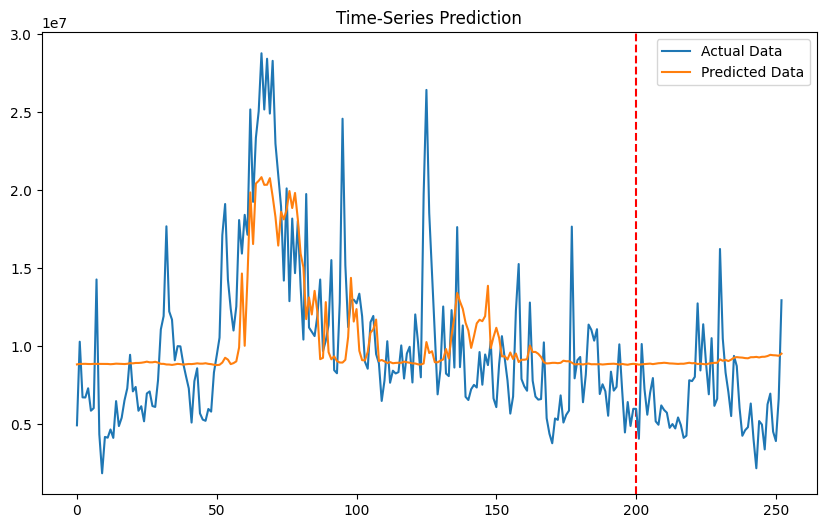

In [39]:
# 모델 예측 결과 출력
# 훈련 데이터셋을 모델에 적용하여 모델 학습
train_predict= model(df_x_ss)
predicted= train_predict.data.numpy()
label_y= df_y_ms.data.numpy()

# 정규화했던것 해제하여 모델학습
predicted= ms.inverse_transform(predicted)
label_y= ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200, c='r', linestyle='--')  ## 1

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label= 'Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()

- 파란색: 실제 레이블에 대한 출력결과
- 주황색: 모델이 예측한 결과
- 현재 결과 나쁨 -> 모델 변경 고려해보자
- GRU로 비교해보자